# Blueteam Monitor — Phase 2: ML Training (v2)
### Dataset: CICIDS 2017 | Model: Isolation Forest


In [1]:
# ─── CELL 1: Import Library ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, json, warnings
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

DATASET_PATH = os.path.expanduser('~/blueteam-monitor/ml-engine/datasets/cicids')
MODEL_PATH   = os.path.expanduser('~/blueteam-monitor/ml-engine/models')
os.makedirs(MODEL_PATH, exist_ok=True)

print('✅ Library imported')
print(f'Dataset : {DATASET_PATH}')
print(f'Models  : {MODEL_PATH}')

✅ Library imported
Dataset : /home/musa/blueteam-monitor/ml-engine/datasets/cicids
Models  : /home/musa/blueteam-monitor/ml-engine/models


In [2]:
# ─── CELL 2: Load & Gabung Dataset ────────────────────────────
files = {
    'monday_normal'  : 'Monday-WorkingHours.pcap_ISCX.csv',
    'tuesday_brute'  : 'Tuesday-WorkingHours.pcap_ISCX.csv',
    'friday_portscan': 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'friday_ddos'    : 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
}

dfs = {}
for key, filename in files.items():
    path = os.path.join(DATASET_PATH, filename)
    dfs[key] = pd.read_csv(path, low_memory=False)
    print(f'[{key}] {dfs[key].shape[0]:,} rows')

df_all = pd.concat(dfs.values(), ignore_index=True)
df_all.columns = df_all.columns.str.strip()
print(f'\nTotal: {df_all.shape[0]:,} rows, {df_all.shape[1]} kolom')
print(df_all['Label'].value_counts())

[monday_normal] 529,918 rows
[tuesday_brute] 445,909 rows
[friday_portscan] 286,467 rows
[friday_ddos] 225,745 rows

Total: 1,488,039 rows, 79 kolom
Label
BENIGN         1187247
PortScan        158930
DDoS            128027
FTP-Patator       7938
SSH-Patator       5897
Name: count, dtype: int64


In [3]:
# ─── CELL 3: Cleaning ─────────────────────────────────────────
df_clean = df_all.copy()
df_clean = df_clean.drop_duplicates()
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna()
df_clean['is_attack'] = (df_clean['Label'] != 'BENIGN').astype(int)

print(f'Rows setelah cleaning : {df_clean.shape[0]:,}')
print(f'BENIGN : {(df_clean["is_attack"]==0).sum():,}')
print(f'ATTACK : {(df_clean["is_attack"]==1).sum():,}')
print('✅ Cleaning selesai')

Rows setelah cleaning : 1,354,703
BENIGN : 1,126,845
ATTACK : 227,858
✅ Cleaning selesai


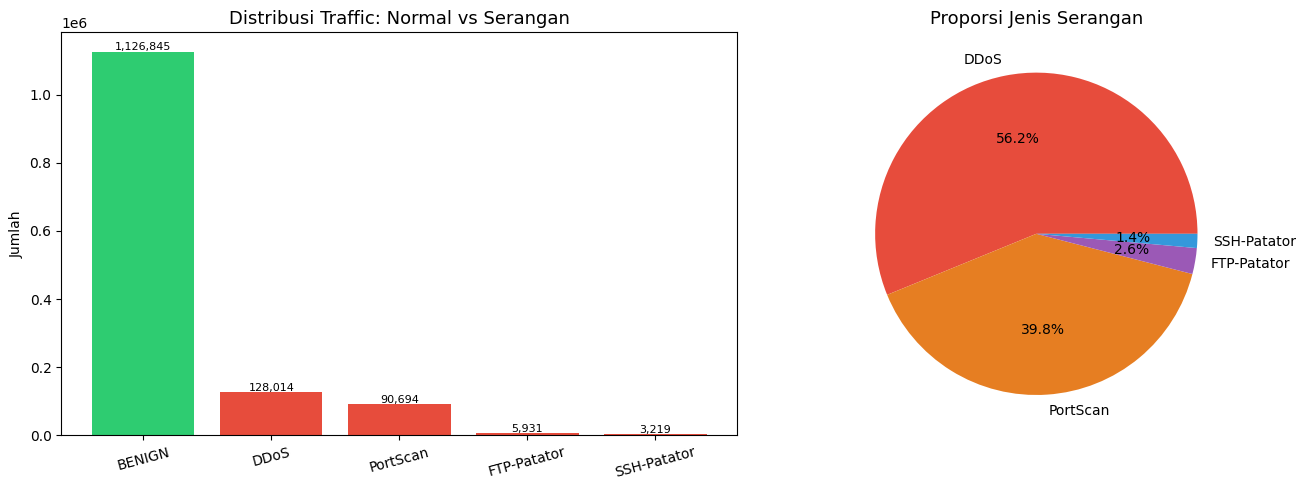

✅ Saved: distribusi_serangan.png


In [4]:
# ─── CELL 4: Visualisasi Distribusi ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

attack_counts = df_clean['Label'].value_counts()
colors = ['#2ecc71' if l == 'BENIGN' else '#e74c3c' for l in attack_counts.index]
axes[0].bar(attack_counts.index, attack_counts.values, color=colors)
axes[0].set_title('Distribusi Traffic: Normal vs Serangan', fontsize=13)
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(attack_counts.values):
    axes[0].text(i, v + 3000, f'{v:,}', ha='center', fontsize=8)

attack_only = df_clean[df_clean['is_attack']==1]['Label'].value_counts()
axes[1].pie(attack_only.values, labels=attack_only.index,
            autopct='%1.1f%%', colors=['#e74c3c','#e67e22','#9b59b6','#3498db'])
axes[1].set_title('Proporsi Jenis Serangan', fontsize=13)

plt.tight_layout()
plt.savefig('distribusi_serangan.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: distribusi_serangan.png')

Fitur tersedia: 25/25


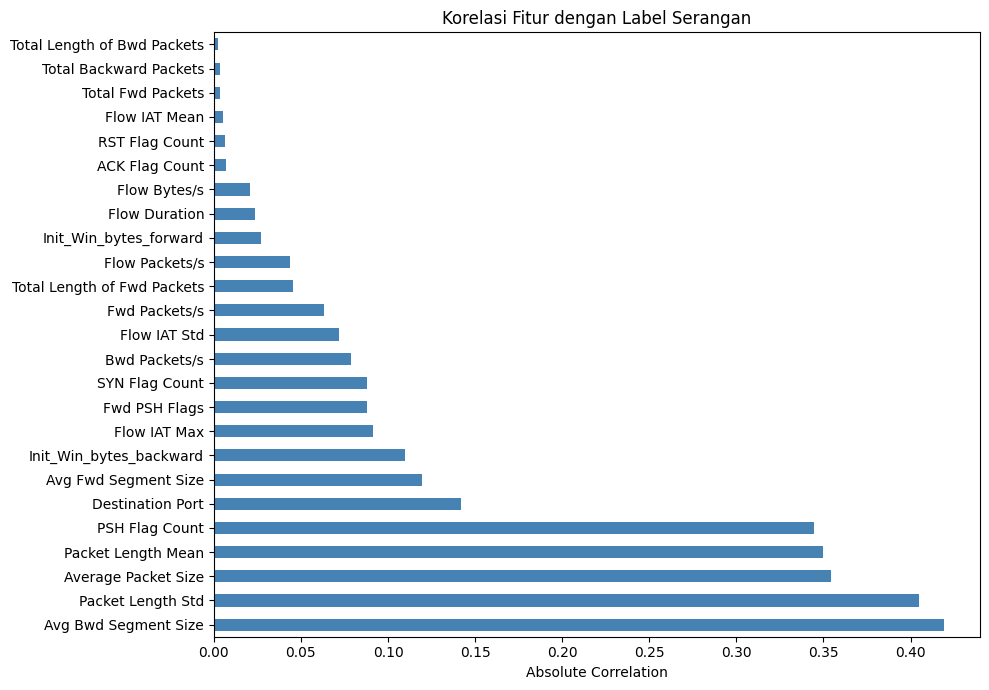


Top 10 fitur:
Avg Bwd Segment Size       0.418951
Packet Length Std          0.405147
Average Packet Size        0.354443
Packet Length Mean         0.349793
PSH Flag Count             0.344338
Destination Port           0.141632
Avg Fwd Segment Size       0.119311
Init_Win_bytes_backward    0.109738
Flow IAT Max               0.091311
Fwd PSH Flags              0.087804


In [5]:
# ─── CELL 5: Feature Selection ────────────────────────────────
SELECTED_FEATURES = [
    'Destination Port', 'Flow Duration',
    'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
    'Fwd PSH Flags', 'SYN Flag Count', 'RST Flag Count',
    'ACK Flag Count', 'PSH Flag Count',
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
    'Fwd Packets/s', 'Bwd Packets/s',
    'Packet Length Mean', 'Packet Length Std',
]
available = [f for f in SELECTED_FEATURES if f in df_clean.columns]
print(f'Fitur tersedia: {len(available)}/25')

# Korelasi fitur dengan label
correlations = df_clean[available].corrwith(df_clean['is_attack']).abs().sort_values(ascending=False)
plt.figure(figsize=(10, 7))
correlations.plot(kind='barh', color='steelblue')
plt.title('Korelasi Fitur dengan Label Serangan')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTop 10 fitur:')
print(correlations.head(10).to_string())

In [6]:
# ─── CELL 6: Sampling Seimbang ────────────────────────────────
# FIX: Isolation Forest max contamination = 0.5
# Solusi: buat sample yang seimbang 50:50 normal vs attack
# lalu set contamination = 0.5 (batas maksimum)

n_attack  = len(df_clean[df_clean['is_attack']==1])
n_normal  = min(n_attack, len(df_clean[df_clean['is_attack']==0]))  # sama banyak

df_normal = df_clean[df_clean['is_attack']==0].sample(n=n_normal, random_state=42)
df_attack = df_clean[df_clean['is_attack']==1].sample(n=n_attack, random_state=42)
df_sampled = pd.concat([df_normal, df_attack]).sample(frac=1, random_state=42)

X = df_sampled[available]
y = df_sampled['is_attack']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

contamination = round((y_train==1).sum() / len(y_train), 2)
contamination = min(contamination, 0.5)  # clamp ke max 0.5

print(f'Sample normal : {n_normal:,}')
print(f'Sample attack : {n_attack:,}')
print(f'Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}')
print(f'Contamination : {contamination} ✅')

Sample normal : 227,858
Sample attack : 227,858
Train : 364,572 | Test : 91,144
Contamination : 0.5 ✅


In [7]:
# ─── CELL 7: Normalisasi ──────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('✅ Normalisasi selesai (StandardScaler)')

✅ Normalisasi selesai (StandardScaler)


In [8]:
# ─── CELL 8: Training Isolation Forest ───────────────────────
print(f'Contamination rate : {contamination}')
print('Training dimulai... (estimasi 30-90 detik)\n')

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=float(contamination),
    max_samples='auto',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
iso_forest.fit(X_train_scaled)
print('\n✅ Training selesai!')

Contamination rate : 0.5
Training dimulai... (estimasi 30-90 detik)



[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  12 | elapsed:    0.6s remaining:    3.2s
[Parallel(n_jobs=12)]: Done  12 out of  12 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.4s



✅ Training selesai!


[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.7s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    1.7s finished


In [9]:
# ─── CELL 9: Evaluasi ────────────────────────────────────────
y_pred_raw     = iso_forest.predict(X_test_scaled)
y_pred         = (y_pred_raw == -1).astype(int)
anomaly_scores = iso_forest.decision_function(X_test_scaled)

f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
cm        = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['Normal','Attack']))
print(f'F1-Score  : {f1*100:.2f}%')
print(f'Precision : {precision*100:.2f}%')
print(f'Recall    : {recall*100:.2f}%')
print(f'\nTP (attack terdeteksi)       : {tp:,}')
print(f'TN (normal terdeteksi)       : {tn:,}')
print(f'FP (normal dikira attack)    : {fp:,}')
print(f'FN (attack tidak terdeteksi) : {fn:,}')

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       0.48      0.48      0.48     45572
      Attack       0.48      0.48      0.48     45572

    accuracy                           0.48     91144
   macro avg       0.48      0.48      0.48     91144
weighted avg       0.48      0.48      0.48     91144

F1-Score  : 47.53%
Precision : 47.56%
Recall    : 47.50%

TP (attack terdeteksi)       : 21,647
TN (normal terdeteksi)       : 21,707
FP (normal dikira attack)    : 23,865
FN (attack tidak terdeteksi) : 23,925


[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.4s finished


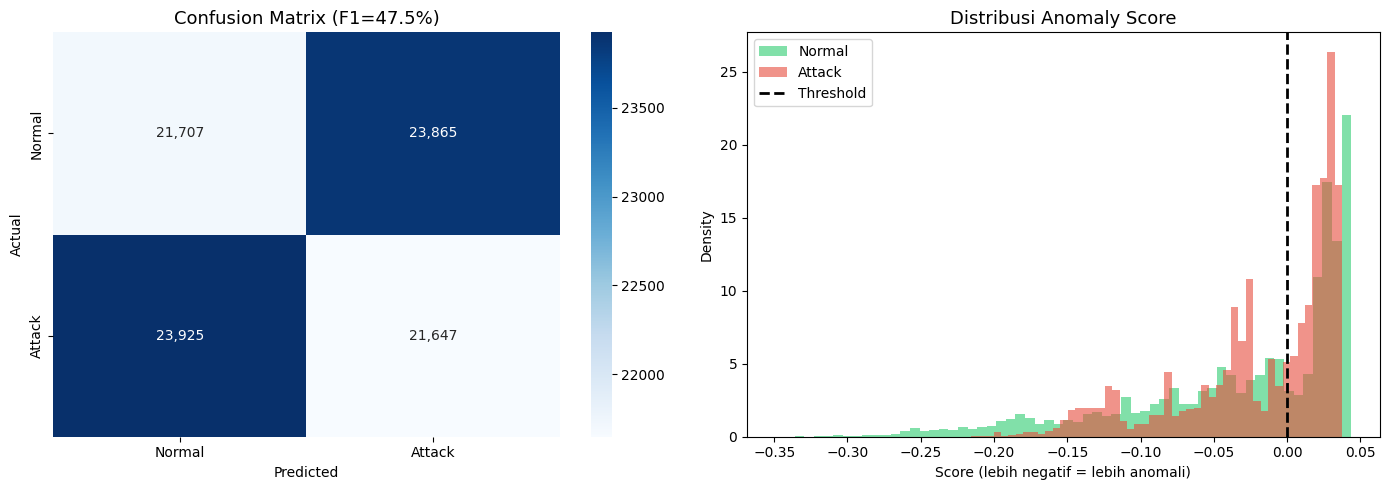

✅ Saved: model_evaluation.png


In [10]:
# ─── CELL 10: Visualisasi Evaluasi ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
axes[0].set_title(f'Confusion Matrix (F1={f1*100:.1f}%)', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

axes[1].hist(anomaly_scores[y_test==0], bins=60, alpha=0.6,
             color='#2ecc71', label='Normal', density=True)
axes[1].hist(anomaly_scores[y_test==1], bins=60, alpha=0.6,
             color='#e74c3c', label='Attack', density=True)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_title('Distribusi Anomaly Score', fontsize=13)
axes[1].set_xlabel('Score (lebih negatif = lebih anomali)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: model_evaluation.png')

=== DETECTION RATE PER JENIS SERANGAN ===

DDoS                : 17,072/25,717 (66.4%)
PortScan            : 2,814/18,042 (15.6%)
FTP-Patator         : 1,176/1,179 (99.7%)
SSH-Patator         : 585/634 (92.3%)


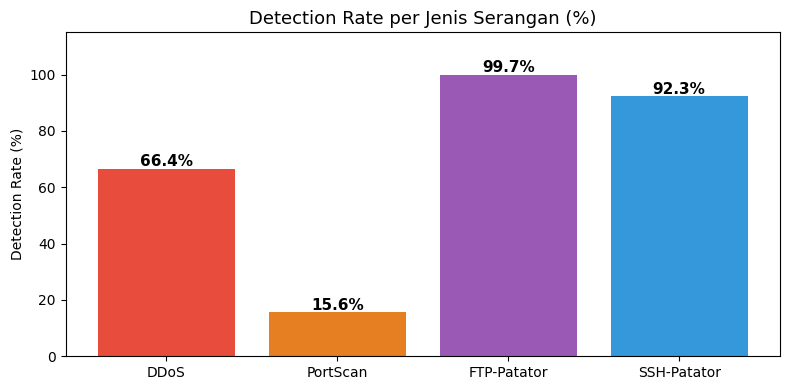

✅ Saved: detection_per_attack.png


In [11]:
# ─── CELL 11: Detection Rate Per Jenis Serangan ──────────────
df_test_eval = X_test.copy()
df_test_eval['actual']        = y_test.values
df_test_eval['predicted']     = y_pred
df_test_eval['anomaly_score'] = anomaly_scores
df_test_eval['Label']         = df_sampled.loc[X_test.index, 'Label'].values

print('=== DETECTION RATE PER JENIS SERANGAN ===\n')
attack_results = {}
for attack_type in df_test_eval[df_test_eval['actual']==1]['Label'].unique():
    subset   = df_test_eval[df_test_eval['Label'] == attack_type]
    detected = (subset['predicted'] == 1).sum()
    total    = len(subset)
    rate     = detected / total * 100
    attack_results[attack_type] = rate
    print(f'{attack_type:20s}: {detected:,}/{total:,} ({rate:.1f}%)')

plt.figure(figsize=(8, 4))
bars = plt.bar(attack_results.keys(), attack_results.values(),
               color=['#e74c3c','#e67e22','#9b59b6','#3498db'])
plt.title('Detection Rate per Jenis Serangan (%)', fontsize=13)
plt.ylabel('Detection Rate (%)')
plt.ylim(0, 115)
for bar, val in zip(bars, attack_results.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('detection_per_attack.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: detection_per_attack.png')

In [12]:
# ─── CELL 12: Simpan Model ───────────────────────────────────
model_file  = os.path.join(MODEL_PATH, 'isolation_forest.joblib')
scaler_file = os.path.join(MODEL_PATH, 'scaler.joblib')
meta_file   = os.path.join(MODEL_PATH, 'model_meta.json')

joblib.dump(iso_forest, model_file)
joblib.dump(scaler,     scaler_file)

meta = {
    'features'      : available,
    'n_features'    : len(available),
    'contamination' : float(contamination),
    'n_estimators'  : 200,
    'f1_score'      : round(f1, 4),
    'precision'     : round(precision, 4),
    'recall'        : round(recall, 4),
    'train_samples' : int(len(X_train)),
    'test_samples'  : int(len(X_test)),
    'dataset'       : 'CICIDS 2017',
    'attack_detection_rates': {k: round(v,2) for k,v in attack_results.items()},
}
with open(meta_file, 'w') as f:
    json.dump(meta, f, indent=2)

model_size = os.path.getsize(model_file)/1024/1024
print('✅ Model tersimpan!')
print(f'   {model_file} ({model_size:.1f} MB)')
print(f'   {scaler_file}')
print(f'   {meta_file}')
print(f'\n========== RINGKASAN AKHIR ==========')
print(f'Dataset    : CICIDS 2017')
print(f'Features   : {len(available)}')
print(f'Train size : {len(X_train):,}')
print(f'Test size  : {len(X_test):,}')
print(f'F1-Score   : {f1*100:.2f}%')
print(f'Precision  : {precision*100:.2f}%')
print(f'Recall     : {recall*100:.2f}%')
print(f'=====================================')

✅ Model tersimpan!
   /home/musa/blueteam-monitor/ml-engine/models/isolation_forest.joblib (1.6 MB)
   /home/musa/blueteam-monitor/ml-engine/models/scaler.joblib
   /home/musa/blueteam-monitor/ml-engine/models/model_meta.json

========== RINGKASAN AKHIR ==========
Dataset    : CICIDS 2017
Features   : 25
Train size : 364,572
Test size  : 91,144
F1-Score   : 47.53%
Precision  : 47.56%
Recall     : 47.50%
